In [1]:
import h5py
import numpy as np
import pandas as pd

import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
import math

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
!curl https://zenodo.org/records/2603256/files/train.h5?download=1 -o toptag.h5

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  990M  100  990M    0     0  18.5M      0  0:00:53  0:00:53 --:--:-- 21.4M


In [4]:
fileIN = "toptag.h5"
f = h5py.File(fileIN)
# and see what it contains
print(list(f.keys()))

['table']


In [5]:
df = pd.read_hdf(fileIN, 'table')
df

,E_0,PX_0,PY_0,PZ_0,E_1,PX_1,PY_1,PZ_1,E_2,PX_2,...,E_199,PX_199,PY_199,PZ_199,truthE,truthPX,truthPY,truthPZ,ttv,is_signal_new
375,474.071136,-250.347031,-223.651962,-334.738098,103.236237,-48.866222,-56.790775,-71.025490,105.255569,-55.415001,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
377,150.504532,120.062393,76.852005,-48.274265,82.257057,63.801739,42.754807,-29.454842,48.573559,36.763199,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
378,251.645386,10.427651,-147.573746,203.564880,104.147797,10.718256,-54.497948,88.101395,78.043213,5.724113,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
379,451.566132,129.885437,-99.066292,-420.984100,208.410919,59.033958,-46.177090,-194.467941,190.183304,54.069675,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
380,399.093903,-168.432083,-47.205597,-358.717438,273.691956,-121.926941,-30.803854,-243.088928,152.837219,-44.400204,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,206.171997,13.942102,114.328499,-171.001465,231.602356,19.010832,92.303848,-211.561432,95.868248,0.411594,...,0.0,0.0,0.0,0.0,1301.364624,48.551048,674.270081,-1098.891968,0,1
591,263.984161,-40.649391,-104.321312,239.065552,238.690689,8.786323,-101.236137,215.979828,126.197868,5.939164,...,0.0,0.0,0.0,0.0,1550.415405,-38.385075,-626.145813,1406.682983,0,1
592,61.417538,42.901291,43.947723,-0.436818,45.521763,31.723654,32.643845,-0.469300,44.801167,29.730831,...,0.0,0.0,0.0,0.0,654.942383,394.933441,467.778076,-162.717285,0,1
593,261.215302,12.780115,-132.699203,224.635300,224.066376,52.028233,-101.145271,193.050354,67.573616,17.166769,...,0.0,0.0,0.0,0.0,1100.826904,220.153702,-566.737549,901.328003,0,1


In [6]:
# each row of the dataframe is a jet, each constituient is a particle, the only features are the four momentum
# Converting dataframe into a usable dataset for a transformer model

class JetDataset(Dataset):

    def __init__(self, df):

        self.jets = list()
        self.labels = list()
        for index, row in df.iterrows():

            tensor = torch.tensor(row.values, dtype=torch.float)
            self.jets.append(tensor[:-6].reshape(-1, 4))
            self.labels.append(tensor[-1].item())

    def __len__(self):
        return len(self.jets)

    def __getitem__(self, index):
        return self.jets[index], self.labels[index]


In [7]:
dataset = JetDataset(df)

In [8]:
class MAB(nn.Module):
    def __init__(self, dim_Q, dim_K, dim_V, num_heads, bias = True, ln=False):
        super(MAB, self).__init__()
        self.dim_V = dim_V
        self.num_heads = num_heads
        self.fc_q = nn.Linear(dim_Q, dim_V, bias = bias)
        self.fc_k = nn.Linear(dim_K, dim_V, bias = bias)
        self.fc_v = nn.Linear(dim_K, dim_V, bias = bias)
        if ln:
            self.ln0 = nn.LayerNorm(dim_V)
            self.ln1 = nn.LayerNorm(dim_V)
        self.fc_o = nn.Linear(dim_V, dim_V, bias = bias)

    def forward(self, Q, K):
        Q = self.fc_q(Q)
        K, V = self.fc_k(K), self.fc_v(K)

        dim_split = self.dim_V // self.num_heads
        Q_ = torch.cat(Q.split(dim_split, 2), 0)
        K_ = torch.cat(K.split(dim_split, 2), 0)
        V_ = torch.cat(V.split(dim_split, 2), 0)

        A = torch.softmax(Q_.bmm(K_.transpose(1,2))/math.sqrt(self.dim_V), 2)
        O = torch.cat((Q_ + A.bmm(V_)).split(Q.size(0), 0), 2)
        O = O if getattr(self, 'ln0', None) is None else self.ln0(O)
        O = O + F.relu(self.fc_o(O))
        O = O if getattr(self, 'ln1', None) is None else self.ln1(O)
        return O

class SAB(nn.Module):
    def __init__(self, dim_in, dim_out, num_heads, ln=False, bias=True,):
        super(SAB, self).__init__()
        self.mab = MAB(dim_in, dim_in, dim_out, num_heads, ln=ln, bias=bias)

    def forward(self, X):
        return self.mab(X, X)

# A one layer transformer (one self attention block)
class SetTransformer(nn.Module):
    def __init__(self, dim_input, dim_output, num_particles_per_jet, dim_hidden=64, num_heads=8, bias=True, ln=False):
        super(SetTransformer, self).__init__()
        self.enc = nn.Sequential(
                SAB(dim_input, dim_hidden, num_heads, ln=ln, bias=bias),
              )
        self.pool = nn.AvgPool1d(num_particles_per_jet)
        self.norm = nn.BatchNorm1d(dim_hidden)
        self.fc = nn.Sequential(
            nn.Linear(dim_hidden, 64, bias = bias),
            nn.LeakyReLU(),
            nn.Linear(64,16, bias = bias),
            nn.LeakyReLU(),
            nn.Linear(16,dim_output, bias = bias),
        )

    def forward(self, X):
        X_ = self.pool(self.enc(X).transpose(1, 2)).squeeze(dim=-1)
        X_ = self.fc(self.norm(X_))
        return X_

In [9]:
torch.cuda.is_available()

True

In [12]:
# define model, dataloaders, optimizers, etc.
device = "cuda" if torch.cuda.is_available() else "cpu"

dim_in = 4
dim_output = 1
num_particles_per_jet = 200
num_heads = 4
bias = True
model = SetTransformer(dim_in, dim_output, num_particles_per_jet, num_heads = num_heads, bias = bias).to(device)


dataset_size = len(dataset)  # use a smaller number of datapoints for debugging
num_train = int(dataset_size * 0.8)
num_test = int(dataset_size * 0.1)
num_val = dataset_size - num_train - num_test

subset_indices_train = list(range(num_train))
subset_indices_val = list(range(num_train,num_train+num_val))
subset_indices_test = list(range(num_train+num_val, dataset_size))

train_subset = Subset(dataset, subset_indices_train)
val_subset = Subset(dataset, subset_indices_val)
test_subset = Subset(dataset, subset_indices_test)

train_dataloader = DataLoader(train_subset, batch_size=512, shuffle=True)
val_dataloader = DataLoader(val_subset, batch_size=512, shuffle=True)
test_dataloader = DataLoader(test_subset, batch_size=512, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=0.0001)

m = nn.Sigmoid()
mm = nn.BCELoss()

In [ ]:
# training loop

epochs = 100

for epoch in range(epochs):

    losses = []

    model.train()
    for batch in iter(train_dataloader):

        X, y = batch
        
        X = X.to(device)
        y = y.to(device)
        
        output = model(X).squeeze(dim=1).to(torch.float64)

        loss = mm(m(output), y)

        losses.append(loss.detach().cpu().item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # print(f"Epoch {epoch} batch loss {loss}")

    print(f"Epoch {epoch}, train loss {sum(losses)/len(losses)}")

    model.eval()
    val_losses = []
    with torch.no_grad():

        for batch in iter(val_dataloader):

            X, y = batch
            
            X = X.to(device)
            y = y.to(device)
        
            output = model(X).squeeze(dim=1).to(torch.float64)

            loss = mm(m(output), y)

            val_losses.append(loss.detach().cpu().item())

    print(f"Epoch {epoch}, val loss {sum(val_losses)/len(val_losses)}")


Epoch 0, train loss 0.27144645045624033
Epoch 0, val loss 0.2718302233342944
Epoch 1, train loss 0.271002066200049
Epoch 1, val loss 0.2698919281605208
Epoch 2, train loss 0.27080911916793216
Epoch 2, val loss 0.2693558970395298


Test set loss: 0.2719916131626236
Test accuracy: 0.8838728323699422


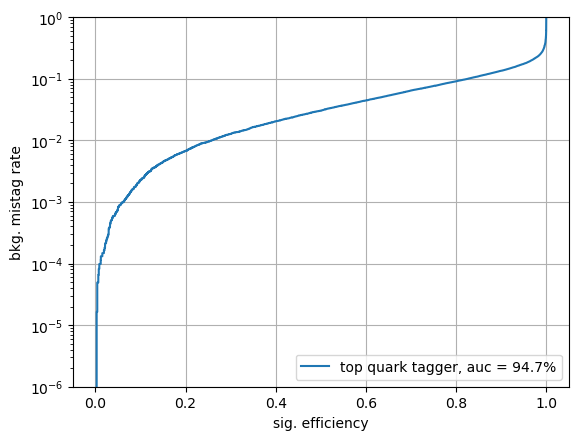

In [16]:
# testing on test set

model.eval()

test_losses = []
test_logits = []
test_labels_true = []
test_num_correct = 0
with torch.no_grad():

    for batch in iter(test_dataloader):

        X, y = batch
        
        X = X.to(device)
        y = y.to(device)
        
        output = model(X).squeeze(dim=1).to(torch.float64)

        predicted_labels = (output >= 0.5)

        loss = mm(m(output), y)

        test_labels_true.extend(list(y.to(torch.long).detach().cpu().numpy()))
        test_logits.extend(list(output.detach().cpu().numpy()))
        test_losses.append(loss.item())
        test_num_correct += torch.sum(y == predicted_labels).item()

print(f"Test set loss: {sum(test_losses)/len(test_losses)}")
print(f"Test accuracy: {test_num_correct / len(subset_indices_test)}")

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, auc

df = pd.DataFrame()
fpr = {}
tpr = {}
auc1 = {}

plt.figure()

fpr, tpr, threshold = roc_curve(np.array(test_labels_true), np.array(test_logits))

auc1 = auc(fpr, tpr)

plt.plot(tpr,fpr,label='%s tagger, auc = %.1f%%'%("top quark",auc1*100.))

plt.semilogy()
plt.xlabel("sig. efficiency")
plt.ylabel("bkg. mistag rate")
plt.ylim(0.000001,1)
plt.grid(True)
plt.legend(loc='lower right')
plt.show()
